# 1 线性回归
## 1.1 线性回归

回归（regression）使能为一个或多个自变量与因变量之间关系建模的一类方法，表示输入和输出之间的关系。
机器学习领域中的大多数任务都与预测（prediction）有关。当我们想预测一个数值时，就会涉及到回归问题。

## 1.2 线性回归的实现

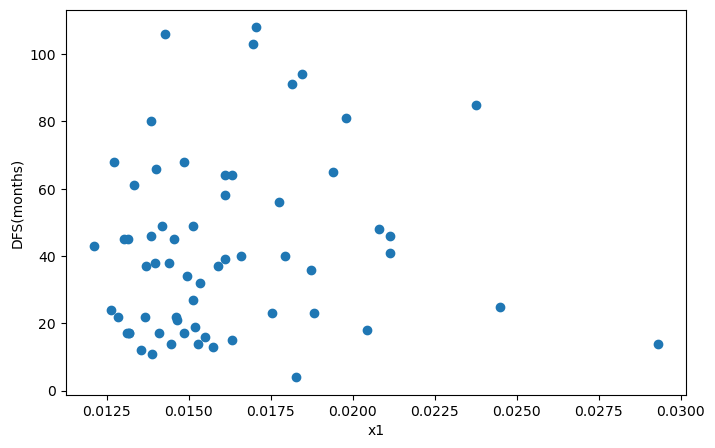

In [70]:
import sys
# sys.path.append('/home/kazundo/WorkSpace/Methods/bioinfo-dl-tutorial/src')
sys.path.append('/xjy/Project1/my_DeepLearnTest/bioinfo-dl-tutorial-main/src')

import torch
import matplotlib.pyplot as plt 
from data.loaders import load_cancer
from utils.DL import DataIter, TryGpu


cancer_mat = load_cancer()
features = torch.tensor(cancer_mat.data.values, device=TryGpu()).float()
labels = torch.tensor(cancer_mat.target, device=TryGpu()).flatten().float()
# features = (features - features.mean(dim=0))/ features.std(dim=0)
features = features/ features.sum(dim=0)

plt.figure(figsize=(8, 5))
plt.scatter(features[:, 0].cpu().detach().numpy(), labels.cpu().detach().numpy())
plt.xlabel('x1')
plt.ylabel('DFS(months)')
plt.show()

### 读取数据集

定义一个Data_iter函数，打乱数据集中的样本并以小批量方式获取数据。

In [71]:
data_iter = DataIter(32, features, labels)
next(iter(data_iter))

[tensor([[0.0144, 0.0159, 0.0131,  ..., 0.0166, 0.0161, 0.0164],
         [0.0161, 0.0155, 0.0160,  ..., 0.0158, 0.0168, 0.0153],
         [0.0187, 0.0151, 0.0154,  ..., 0.0165, 0.0190, 0.0171],
         ...,
         [0.0145, 0.0160, 0.0161,  ..., 0.0169, 0.0150, 0.0159],
         [0.0149, 0.0161, 0.0171,  ..., 0.0155, 0.0157, 0.0146],
         [0.0157, 0.0165, 0.0158,  ..., 0.0171, 0.0166, 0.0182]],
        device='cuda:0'),
 tensor([ 14.,  39.,  36.,  22.,  91.,  34.,  24.,  66.,  19.,  49., 106., 103.,
          32.,  38.,  46.,  11.,  17.,  49.,  17.,  65.,  56.,  64.,  81.,  94.,
          22.,  38.,  16.,  22.,  23.,  45.,  68.,  13.], device='cuda:0')]

### 定义模型



In [72]:
from torch import nn

net = nn.Sequential(nn.Linear(features.shape[1], 1))
net.to(device=TryGpu())
net

Sequential(
  (0): Linear(in_features=1935, out_features=1, bias=True)
)

### 模型初始化参数

In [73]:
for name, pram in net.named_parameters():
    if 'weight' in name:
        pram.data.normal_(0, 0.01)
    if 'bias' in name:
        pram.data.zero_()
net[0].weight.data, net[0].bias.data

(tensor([[ 0.0112, -0.0018, -0.0067,  ..., -0.0097, -0.0081, -0.0012]],
        device='cuda:0'),
 tensor([0.], device='cuda:0'))

### 定义损失函数

计算军方误差用的时MSELoss类，也称为平方 L2 范数。默认情况下返回所有样本的平均值。

In [74]:
loss = nn.MSELoss()

### 定义优化算法

小批量随机梯度下降是一种优化神经网络的标准工具，PyTorch在optim模块中实现了改算法的许多变种。当实例化一个SGD实例时，要指定优化的参数（net.parameters()从模型中获得）以及优化算法所需的超参数字典。小批量随机梯度下降只需要设置lr值。

In [75]:
trainer = torch.optim.SGD(net.parameters(), lr = 0.01)

### 训练

在每个迭代周期里，完整遍历一次数据集（train_data），不停从中获取一个小批量的输入和相应的标签。对于一个小批量，进行以下步骤：
- 调用net(X)生成预测并计算损失l（前向传播）
- 提高进行反向传播来计算梯度
- 通过调用优化器来更新模型参数

In [76]:
epochs = 1000
for epoch in range(epochs):
    total_loss = 0
    for X,y in data_iter:
        l = loss(net(X), y)
        trainer.zero_grad()
        l.backward()
        trainer.step()
        total_loss += l.item() * y.size(0)
    print(f'epoch:{epoch+1},\ttotal_loss:{l:.5f}')

/home/xjy/conda/envs/DL/lib/python3.12/site-packages/torch/nn/modules/loss.py:634: UserWarning: Using a target size (torch.Size([32])) that is different to the input size (torch.Size([32, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
/home/xjy/conda/envs/DL/lib/python3.12/site-packages/torch/nn/modules/loss.py:634: UserWarning: Using a target size (torch.Size([30])) that is different to the input size (torch.Size([30, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


epoch:1,	total_loss:2274.10522
epoch:2,	total_loss:2466.28564
epoch:3,	total_loss:2476.21069
epoch:4,	total_loss:1646.03772
epoch:5,	total_loss:1942.52454
epoch:6,	total_loss:1341.37463
epoch:7,	total_loss:1782.64319
epoch:8,	total_loss:1048.61096
epoch:9,	total_loss:1419.11841
epoch:10,	total_loss:1336.79675
epoch:11,	total_loss:831.65851
epoch:12,	total_loss:1023.68695
epoch:13,	total_loss:447.76126
epoch:14,	total_loss:825.16888
epoch:15,	total_loss:598.71570
epoch:16,	total_loss:1044.41052
epoch:17,	total_loss:971.00739
epoch:18,	total_loss:866.87268
epoch:19,	total_loss:830.03241
epoch:20,	total_loss:719.93292
epoch:21,	total_loss:908.45721
epoch:22,	total_loss:1125.33777
epoch:23,	total_loss:691.27087
epoch:24,	total_loss:556.75909
epoch:25,	total_loss:864.61182
epoch:26,	total_loss:727.11377
epoch:27,	total_loss:579.56531
epoch:28,	total_loss:761.05518
epoch:29,	total_loss:641.09015
epoch:30,	total_loss:987.10370
epoch:31,	total_loss:866.18549
epoch:32,	total_loss:677.39038
epoc

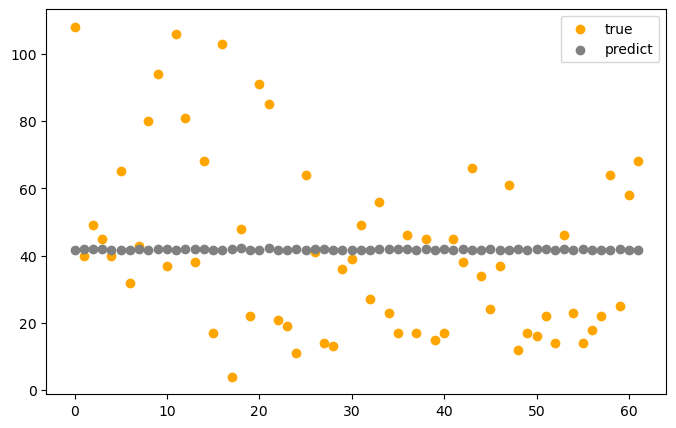

: 

: 

In [ ]:

plt.figure(figsize=(8, 5))
plt.scatter(x = [i for i in range(len(features))], y = labels.cpu().numpy(), c='orange', label='true')
plt.scatter(x = [i for i in range(len(features))], y = net(features).detach().cpu().numpy(), c='grey', label='predict')
plt.legend()
plt.show()